# Repetition-Neighbor CRP

> Compute and visualize transitions between neighbors of repeated items.

The repetition-neighbor CRP analysis examines transitions between items studied near different presentations of the same repeated item. For a repeated item at positions i and j, the analysis tracks transitions from j's neighbors to i's neighborhood (j2i), from i's neighbors to j's neighborhood (i2j), or both.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `mixed_trial_query` | Query string selecting mixed (repeated-item) trials |
| `control_trial_query` | Query string selecting pure (control) trials |
| `control_shuffles` | Number of shuffled control blocks per subject |
| `min_lag` | Minimum spacing between repeated occurrences |
| `max_lag` | Maximum lag to display |
| `direction` | Direction of neighbor transitions |
| `use_lag2` | Include +2 neighbor offsets |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.repneighborcrp import (
    plot_rep_neighbor_crp,
    plot_repneighborcrp_j2i,
    plot_repneighborcrp_i2j,
    plot_repneighborcrp_both,
    repneighborcrp,
    tabulate_trial,
    subject_rep_neighbor_crp,
    test_rep_neighbor_crp_vs_control,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
mixed_trial_query = 'data["list_type"] > 2'
control_trial_query = 'data["list_type"] == 1'
control_shuffles = 10
min_lag = 4
max_lag = 3
direction = "both"
use_lag2 = True

In [4]:
#| code-summary: Load data and build control dataset
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)
control_dataset = make_control_dataset(
    data, mixed_trial_query, control_trial_query, control_shuffles
)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)

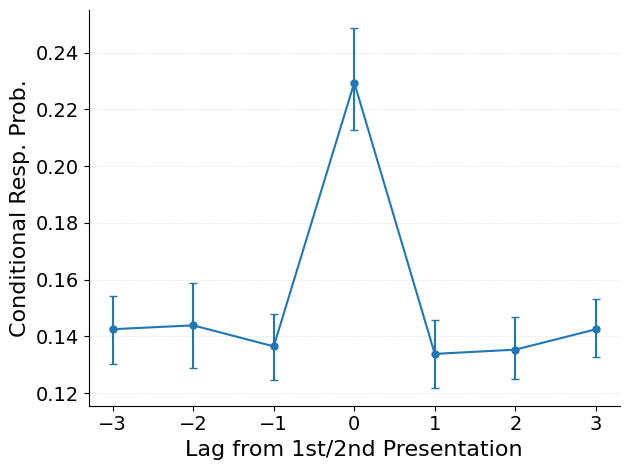

In [5]:
#| code-summary: Plot repetition-neighbor Lag-CRP (observed)
#| label: fig-repneighborcrp
#| fig-cap: "Repetition-neighbor Lag-CRP for transitions between neighbors of repeated items."
plot_rep_neighbor_crp(
    data,
    trial_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    direction=direction,
    use_lag2=use_lag2,
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="mixed")

## Statistical Tests

In [6]:
#| code-summary: Test observed vs control repetition-neighbor CRP
observed_crp = subject_rep_neighbor_crp(
    data, trial_mask, direction, use_lag2, min_lag, max_lag
)
control_crp = subject_rep_neighbor_crp(
    control_dataset, control_mask, direction, use_lag2, min_lag, max_lag
)

result = test_rep_neighbor_crp_vs_control(observed_crp, control_crp, max_lag, direction)

print()
print("=" * 70)
print(f"Statistical Test: {direction}")
print("=" * 70)
if direction == "j2i":
    print("Tests whether j+1/j+2 -> i-neighbors transitions are elevated vs control.")
    print("Significant positive effects support study-phase retrieval at P2.")
elif direction == "i2j":
    print("Tests whether i+1/i+2 -> j-neighbors transitions are elevated vs control.")
    print("(Control condition for asymmetric predictions.)")
else:
    print("Tests both directions combined.")
print()
print(result)


Statistical Test: both
Tests both directions combined.

Direction: both
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -3 |    1.809     0.0793 |    199.0     0.0579 |     0.0092
   -2 |    1.378     0.1773 |    249.0     0.2872 |     0.0098
   -1 |    2.476     0.0184 |    185.0     0.0327 |     0.0161
    0 |    5.159     0.0000 |     71.0     0.0000 |     0.0396
    1 |    2.935     0.0059 |    156.0     0.0082 |     0.0175
    2 |    2.716     0.0103 |    168.0     0.0151 |     0.0155
    3 |    4.734     0.0000 |     95.0     0.0002 |     0.0211


---

## Reference

In [7]:
#| echo: false
show_doc(plot_rep_neighbor_crp)

---

### plot_rep_neighbor_crp

>      plot_rep_neighbor_crp (datasets:Union[Sequence[jaxcmr.typing.RecallDatase
>                             t],jaxcmr.typing.RecallDataset], trial_masks:Union
>                             [Sequence[jaxtyping.Bool[Array,'trial_count']],jax
>                             typing.Bool[Array,'trial_count']], max_lag:int=3,
>                             min_lag:int=4, direction:str='both',
>                             use_lag2:bool=True,
>                             color_cycle:Optional[list[str]]=None,
>                             labels:Optional[Sequence[str]]=None,
>                             contrast_name:Optional[str]=None,
>                             axis:Optional[matplotlib.axes._axes.Axes]=None,
>                             confidence_level:float=0.95)

*Plot repetition-neighbor lag-CRP with CIs.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | Datasets containing trial data to plot. |
| trial_masks | Union |  | Masks to filter trials in datasets. |
| max_lag | int | 3 | Maximum lag to display. |
| min_lag | int | 4 | Minimum spacing between repeated occurrences. |
| direction | str | both | Direction of neighbor transitions. |
| use_lag2 | bool | True | Include +2 neighbor offsets when True. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels for each dataset. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Axes with the neighbor CRP plot.** |

In [8]:
#| echo: false
show_doc(plot_repneighborcrp_j2i)

---

### plot_repneighborcrp_j2i

>      plot_repneighborcrp_j2i (datasets:Union[Sequence[jaxcmr.typing.RecallData
>                               set],jaxcmr.typing.RecallDataset], trial_masks:U
>                               nion[Sequence[jaxtyping.Bool[Array,'trial_count'
>                               ]],jaxtyping.Bool[Array,'trial_count']],
>                               max_lag:int=3, min_lag:int=4,
>                               color_cycle:Optional[list[str]]=None,
>                               labels:Optional[Sequence[str]]=None,
>                               contrast_name:Optional[str]=None,
>                               axis:Optional[matplotlib.axes._axes.Axes]=None,
>                               confidence_level:float=0.95)

*Return plot configured for j-neighbor → i transitions.*

In [9]:
#| echo: false
show_doc(plot_repneighborcrp_i2j)

---

### plot_repneighborcrp_i2j

>      plot_repneighborcrp_i2j (datasets:Union[Sequence[jaxcmr.typing.RecallData
>                               set],jaxcmr.typing.RecallDataset], trial_masks:U
>                               nion[Sequence[jaxtyping.Bool[Array,'trial_count'
>                               ]],jaxtyping.Bool[Array,'trial_count']],
>                               max_lag:int=3, min_lag:int=4,
>                               color_cycle:Optional[list[str]]=None,
>                               labels:Optional[Sequence[str]]=None,
>                               contrast_name:Optional[str]=None,
>                               axis:Optional[matplotlib.axes._axes.Axes]=None,
>                               confidence_level:float=0.95)

*Return plot configured for i-neighbor → j transitions.*

In [10]:
#| echo: false
show_doc(plot_repneighborcrp_both)

---

### plot_repneighborcrp_both

>      plot_repneighborcrp_both (datasets:Union[Sequence[jaxcmr.typing.RecallDat
>                                aset],jaxcmr.typing.RecallDataset], trial_masks
>                                :Union[Sequence[jaxtyping.Bool[Array,'trial_cou
>                                nt']],jaxtyping.Bool[Array,'trial_count']],
>                                max_lag:int=3, min_lag:int=4,
>                                color_cycle:Optional[list[str]]=None,
>                                labels:Optional[Sequence[str]]=None,
>                                contrast_name:Optional[str]=None,
>                                axis:Optional[matplotlib.axes._axes.Axes]=None,
>                                confidence_level:float=0.95)

*Return plot configured for both j-neighbor → i and i-neighbor → j transitions.*

In [11]:
#| echo: false
show_doc(repneighborcrp)

---

### repneighborcrp

>      repneighborcrp (dataset:jaxcmr.typing.RecallDataset,
>                      direction:Literal['j2i','i2j','both']='both',
>                      use_lag2:bool=True, min_lag:int=4)

*Repetition-neighbor lag-CRP probabilities per lag.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Dataset with ``recalls`` and ``pres_itemnos``. |
| direction | Literal | both | Which neighbor-transition direction to count. |
| use_lag2 | bool | True | Include +2 neighbor offsets when True. |
| min_lag | int | 4 | Minimum spacing between repeated presentations. |
| **Returns** | **Float[Array, 'lags']** |  | **CRP of shape ``(2*L-1,)`` per lag bin.** |

In [12]:
#| echo: false
show_doc(tabulate_trial)

---

### tabulate_trial

>      tabulate_trial (trial:jaxtyping.Integer[Array,'recall_events'],
>                      presentation:jaxtyping.Integer[Array,'study_events'],
>                      direction:Literal['j2i','i2j','both']='j2i',
>                      use_lag2:bool=False, min_lag:int=4)

*Tabulate observed and available lags for a trial.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| trial | Integer[Array, 'recall_events'] |  | Recall events for a single trial. |
| presentation | Integer[Array, 'study_events'] |  | Study events for the trial. |
| direction | Literal | j2i | Which neighbor-transition direction to count. |
| use_lag2 | bool | False | Include +2 neighbor offsets when True. |
| min_lag | int | 4 | Minimum spacing between repeated presentations. |
| **Returns** | **tuple** |  | **Actual and available lag tabulations.** |

In [13]:
#| echo: false
show_doc(subject_rep_neighbor_crp)

---

### subject_rep_neighbor_crp

>      subject_rep_neighbor_crp (dataset:jaxcmr.typing.RecallDataset,
>                                trial_mask:jaxtyping.Bool[Array,'trial_count'],
>                                direction:Literal['j2i','i2j','both']='both',
>                                use_lag2:bool=True, min_lag:int=4,
>                                max_lag:int=3)

*Compute subject-level repetition-neighbor CRP.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset. |
| trial_mask | Bool[Array, 'trial_count'] |  | Boolean mask selecting trials to include. |
| direction | Literal | both | Which neighbor-transition direction to count. |
| use_lag2 | bool | True | Include +2 neighbor offsets when True. |
| min_lag | int | 4 | Minimum spacing between repeated presentations. |
| max_lag | int | 3 | Maximum lag to include in output. |
| **Returns** | **ndarray** |  |  |

In [14]:
#| echo: false
show_doc(test_rep_neighbor_crp_vs_control)

---

### test_rep_neighbor_crp_vs_control

>      test_rep_neighbor_crp_vs_control (observed_crp:numpy.ndarray,
>                                        control_crp:numpy.ndarray,
>                                        max_lag:int=3, direction:str='both')

*Test observed vs control repetition-neighbor CRP.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| observed_crp | ndarray |  | Subject-level CRP from observed data.<br>Shape ``(n_subjects, 2*max_lag+1)``. |
| control_crp | ndarray |  | Subject-level CRP from control data.<br>Shape ``(n_subjects, 2*max_lag+1)``. |
| max_lag | int | 3 | Maximum lag used for labeling. |
| direction | str | both | Direction label for results. |
| **Returns** | **RepNeighborCRPTestResult** |  |  |